# Séance 1 : Fondations Computationnelles — Python pour Mathématiciens

**Objectifs** :
- Prendre en main Python pour l'implémentation d'algorithmes mathématiques.
- Implémenter l'algorithme d'Euclide étendu et le crible d'Ératosthène.
- Mesurer et analyser la complexité algorithmique.

---

# Séance 1 : Fondations Computationnelles — Python pour Mathématiciens

**Objectifs** :
- Prendre en main Python pour l'implémentation d'algorithmes mathématiques.
- Implémenter l'algorithme d'Euclide étendu et le crible d'Ératosthène.
- Mesurer et analyser la complexité algorithmique.

---

## 1. Préparation de l'environnement

Exécutez la cellule suivante pour importer les bibliothèques nécessaires.

In [33]:
import timeit
import matplotlib.pyplot as plt
import math

%matplotlib inline

## 2. Algorithme d'Euclide étendu

### Version récursive

Rappel : l'algorithme retourne $(d, u, v)$ tel que $d = a u + b v = \mathrm{pgcd}(a,b)$.

In [1]:
def euclide_etendu_rec(a, b):
    """
    Algorithme d'Euclide étendu (version récursive).
    Retourne (pgcd, u, v) avec a*u + b*v = pgcd.
    """
    if b == 0:
        return (a, 1, 0)
    else:
        d, u1, v1 = euclide_etendu_rec(b, a % b)
        u = v1
        v = u1 - (a // b) * v1
        return (d, u, v)

In [2]:
# Test rapide
a, b = 240, 46
d, u, v = euclide_etendu_rec(a, b)
print(f"pgcd({a}, {b}) = {d}")
print(f"{a}*{u} + {b}*{v} = {a*u + b*v}")

pgcd(240, 46) = 2
240*-9 + 46*47 = 2


### Version itérative (à compléter)

**Exercice** : Implémentez ci-dessous une version itérative de l'algorithme d'Euclide étendu. Vous pouvez utiliser une boucle `while` et mettre à jour les coefficients.

In [29]:
def euclide_etendu_iter(a, b):
    """
    Version itérative de l'algorithme d'Euclide étendu.
    """
    #trouvons un triplé (d,u,v) tel que a*u+b*v = d avec d = pgcd(a,b)
    do,d1 = a,b
    uo,u1 = 1,0
    vo,v1 = 0,1 
    #ces donnés  initials vérifie bien l'equation
    while d1!=0:
        q= do//d1 # Partie entiere de do/d1
        #relation de recurrence:
        do,d1 = d1,do-q*d1
        uo,u1 = u1,uo-q*u1
        vo,v1 = v1,vo-q*v1 
        #une fois d1=0, la boucle s'arrete est pgcd(a,b)=do
    return do,uo,vo


In [30]:
# Test de votre version itérative
d, u, v = euclide_etendu_iter(240, 46)
assert d == 2 and 240*u + 46*v == 2
print("Test réussi !")
print(f" (d ,u,v )={euclide_etendu_iter(240,46)}")

Test réussi !
 (d ,u,v )=(2, -9, 47)


## 3. Crible d'Ératosthène

### Version de base

In [27]:
def eratosthene(n):
    """
    Retourne la liste des nombres premiers <= n.
    """
    ctr = 0
    if n < 2:
        return []
    est_premier = [True] * (n + 1)
    est_premier[0] = est_premier[1] = False
    for p in range(2, int(n**0.5) + 1):
        if est_premier[p]:
            for multiple in range(p * p, n + 1, p):
                est_premier[multiple] = False
            ctr += 1
    return [i for i, prime in enumerate(est_premier) if prime], ctr

def cont_erat(n):
    return [eratosthene(10**k)[1] for k in range(1, n+1)]

In [28]:
eratosthene_opt(50)

[2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47]

### Version optimisée (nombres impairs uniquement)

**Exercice** : Modifiez le crible pour ne traiter que les nombres impairs (sauf 2).

In [24]:
def eratosthene_opt(n):
    """
    Crible optimisé pour ne parcourir que les impairs.
    """
    if n < 2:
        return []
    if n == 2:
        return [2]
    
    size = (n - 1) // 2 + 1  # taille du nombre impair inferieure à n
    is_prime = [True] * size
    is_prime[0] = False  # 1 n'est pas premier
    
    # p = 3, 5, 7, ..., jusqu'à sqrt(n)
    max_p = int(n**0.5) + 1 # caracteristique de teste nombre premier, la boucle s'arrete 
    
    for k in range(1, size):
        p = 2 * k + 1
        if p > max_p:
            break
        if is_prime[k]:
            start_i = (p * p - 1) // 2  # Premier multiple = p*p
            for j in range(start_i, size, p):
                is_prime[j] = False
    
    # Ajouter les impairs premiers
    primes = [2]  # Initialisation de la liste
    for i in range(1, size):
        if is_prime[i]:
            primes.append(2 * i + 1) #entrer le valeur no nombre premier dans la liste primes[]
    
    return primes

In [26]:
eratosthene_opt(50)

[2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47]

## 4. Analyse de complexité empirique

Nous allons mesurer le temps d'exécution du crible pour différentes valeurs de $n$.

In [31]:
def mesurer_temps(fonction, n, repetitions=5):
    """
    Mesure le temps moyen d'exécution de fonction(n) sur 'repetitions' exécutions.
    """
    timer = timeit.Timer(lambda: fonction(n))
    temps = timer.timeit(number=repetitions)
    return temps / repetitions

In [34]:
valeurs_n = [10**i for i in range(3, 8)]  # 10^3 à 10^7
temps_base = []
temps_opt = []

for n in valeurs_n:
    t_base = mesurer_temps(eratosthene, n, repetitions=3)
    # t_opt = mesurer_temps(eratosthene_opt, n, repetitions=3)  # décommentez quand votre fonction est prête
    temps_base.append(t_base)
    # temps_opt.append(t_opt)
    print(f"n = {n:7d} : temps base = {t_base:.4f} s")

n =    1000 : temps base = 0.0001 s
n =   10000 : temps base = 0.0016 s
n =  100000 : temps base = 0.0162 s
n = 1000000 : temps base = 0.1800 s
n = 10000000 : temps base = 1.8169 s


### Visualisation

On souhaite vérifier que le temps est proportionnel à $n \log \log n$.

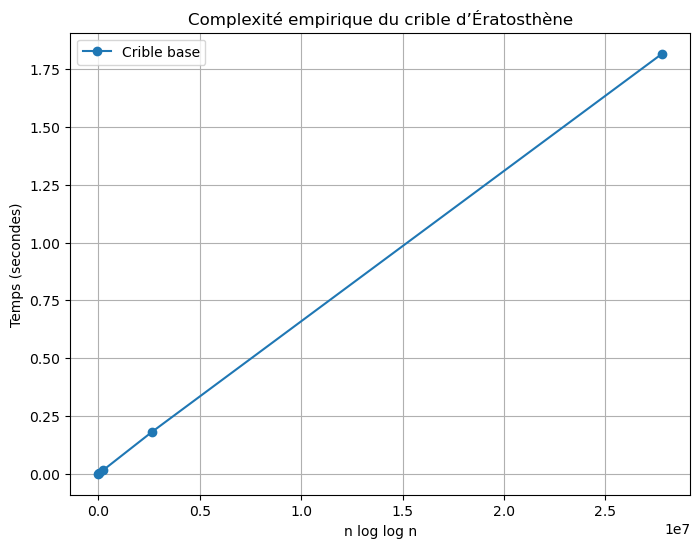

In [35]:
n_loglog = [n * math.log(math.log(n)) if n>2 else 0 for n in valeurs_n]

plt.figure(figsize=(8,6))
plt.plot(n_loglog, temps_base, 'o-', label='Crible base')
# plt.plot(n_loglog, temps_opt, 's-', label='Crible optimisé')  # à décommenter
plt.xlabel('n log log n')
plt.ylabel('Temps (secondes)')
plt.title('Complexité empirique du crible d’Ératosthène')
plt.legend()
plt.grid(True)
plt.show()

**Question** : Le graphique est-il approximativement une droite ? Que peut-on en conclure ?

## 5. Conclusion et rendu

- Assurez-vous que votre notebook contient **toutes** les fonctions demandées (versions récursive et itérative d'Euclide étendu, crible optimisé).
- Ajoutez des commentaires expliquant vos choix d'implémentation.
- Exportez ce notebook au format `.ipynb` et commitez-le dans votre dépôt GitHub.

**Rappel** : Vous pouvez utiliser l'IA comme assistant, mais vous devez comprendre chaque ligne de code et être capable de l'expliquer.